In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('Zomato-data-.xls')
print(df)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [3]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='str')

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 12.7 KB


In [7]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [8]:
df.shape

(148, 7)

In [9]:
df_restaurants=df['listed_in(type)'].unique()
print(df_restaurants)

<ArrowStringArray>
['Buffet', 'Cafes', 'other', 'Dining']
Length: 4, dtype: str


<Axes: xlabel='listed_in(type)', ylabel='count'>

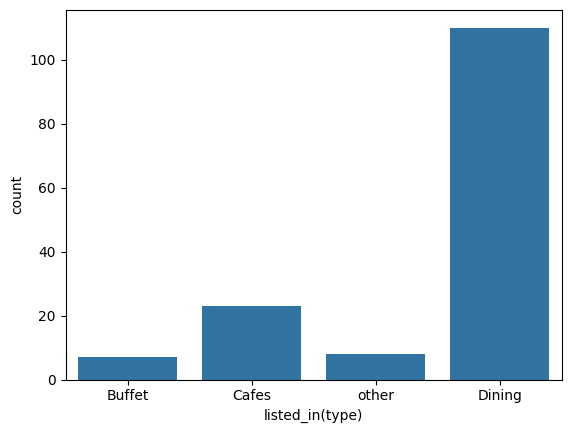

In [10]:
sns.countplot(x='listed_in(type)',data=df)          #1.Different types of restaurants chart

In [11]:
df_orders=df.online_order.value_counts()
print(df_orders)

online_order
No     90
Yes    58
Name: count, dtype: int64


<Axes: xlabel='online_order', ylabel='count'>

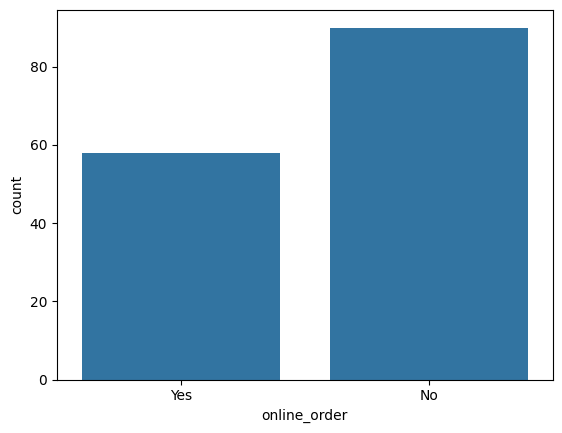

In [12]:
sns.countplot(x='online_order',data=df)     #2.which orders are preferred more

In [13]:
df_relationship=df.groupby('listed_in(type)')['approx_cost(for two people)'].sum().sort_values(ascending=True).reset_index()
print(df_relationship)

  listed_in(type)  approx_cost(for two people)
0          Buffet                         4700
1           other                         5350
2           Cafes                        12550
3          Dining                        39300


<Axes: xlabel='listed_in(type)', ylabel='approx_cost(for two people)'>

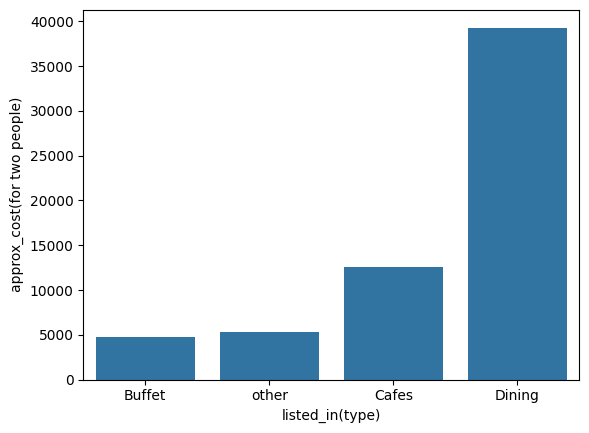

In [14]:
sns.barplot(x='listed_in(type)',y='approx_cost(for two people)',data=df_relationship)   #3.relationship between restaurant name and approx cost for 2 people

In [15]:
df_votes=df.groupby('listed_in(type)')['votes'].sum().sort_values(ascending=False).reset_index()
print(df_votes)

  listed_in(type)  votes
0          Dining  20363
1           other   9367
2           Cafes   6434
3          Buffet   3028


<Axes: xlabel='listed_in(type)', ylabel='votes'>

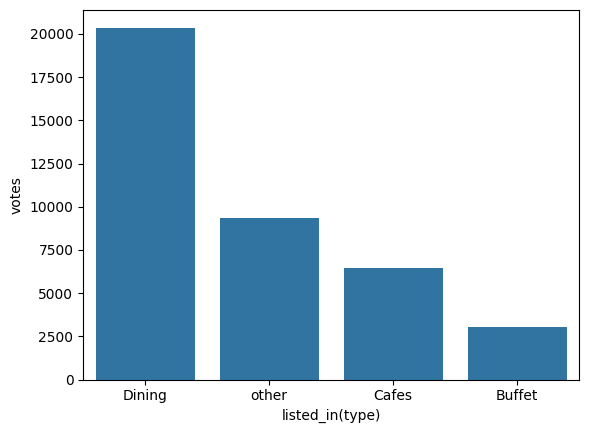

In [16]:
sns.barplot(x='listed_in(type)',y='votes',data=df_votes)   #4.which type of restaurant has more votes

In [17]:
df_book_table=df['book_table'].value_counts()
print(df_book_table)

book_table
No     140
Yes      8
Name: count, dtype: int64


<Axes: xlabel='book_table', ylabel='count'>

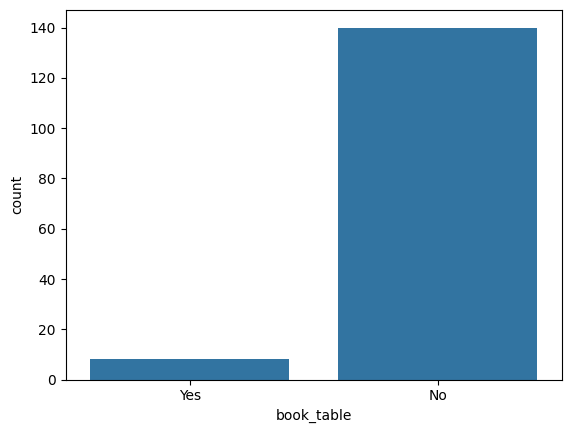

In [18]:
sns.countplot(x='book_table',data=df)   #5.which count is more book table or not

In [19]:
print("Different types of restaurants have been shown through countplot")
print("Offline orders are preferred more")
print("Approx cost for 2 people is more on Dining")
print("Dining type restaurant has been given more votes")
print("People are more who don't book a table")

Different types of restaurants have been shown through countplot
Offline orders are preferred more
Approx cost for 2 people is more on Dining
Dining type restaurant has been given more votes
People are more who don't book a table
